# 04 - Model Training
## Online Shoppers Purchasing Intention Dataset

**Goal of this notebook:**
Using the final engineered features from `03_Feature_Engineering.ipynb`, we now train
**baseline models** and compare two strategies for handling class imbalance. We will:

1. Load the final engineered train/test data.
2. Briefly recap the class imbalance problem (~15.5% positive class).
3. Explain and set up **two imbalance-handling strategies**:
   - **Strategy A - `class_weight='balanced'`**: tell the model to penalize
     misclassifying the minority class more heavily, without changing the data itself.
   - **Strategy B - SMOTE (Synthetic Minority Oversampling Technique)**: generate
     synthetic minority-class samples to balance the training data itself, applied
     ONLY to the training set (never to test data).
4. Train **3 algorithms** (Random Forest, XGBoost, LightGBM) x **2 strategies** = 6
   baseline models.
5. Evaluate all 6 models on the untouched test set using imbalance-appropriate
   metrics (Precision, Recall, F1, ROC-AUC, PR-AUC).
6. Compare results in a summary table and visualizations to pick promising
   candidates.
7. Save all trained baseline models to disk for the next notebook.

> **Note:** This notebook focuses on getting solid **baseline** models trained and
> compared fairly. Deep **hyperparameter tuning** and **k-fold cross-validation**
> happen in `05_Evaluation_Tuning_CV.ipynb`, applied to the most promising
> configuration(s) found here.

> **Why SMOTE must only touch the training set:** SMOTE creates synthetic examples by
> interpolating between existing minority-class samples. If applied before splitting
> (or to the test set), synthetic points could end up "leaking" information about test
> samples into training, giving unrealistically optimistic evaluation results. We
> already split train/test in Notebook 02, so applying SMOTE now (only to
> `X_train`/`y_train`) is safe.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Final Engineered Data (output of Notebook 03)

In [2]:
# We use the UNSCALED feature-engineered version, since Random Forest, XGBoost, and
# LightGBM are all tree-based ensemble models and do not require feature scaling.
X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test = pd.read_csv('../data/processed/X_test_fe.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Train purchase rate: {y_train.mean():.4f}")
print(f"Test purchase rate:  {y_test.mean():.4f}")


X_train shape: (9764, 38)
X_test shape:  (2441, 38)
Train purchase rate: 0.1563
Test purchase rate:  0.1565


## 3. Recap: Class Imbalance

Only ~15.5% of sessions convert to a purchase. If we ignore this, models tend to
become biased towards predicting the majority class ("No Purchase") and will have
poor **Recall** for the minority class (i.e., they will miss a lot of actual buyers) -
which defeats the whole business purpose of this model (identifying likely buyers).


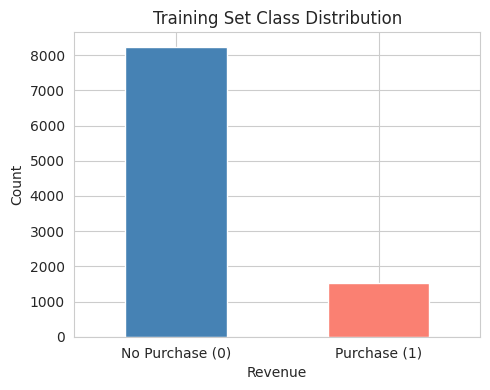

Revenue
0    8238
1    1526
Name: count, dtype: int64


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
y_train.value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_xticklabels(['No Purchase (0)', 'Purchase (1)'], rotation=0)
ax.set_title('Training Set Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(y_train.value_counts())


## 4. Strategy A - Class Weighting

Each of our three libraries supports weighting the minority class more heavily
during training, without altering the training data:

- **Random Forest**: `class_weight='balanced'` (scikit-learn automatically computes
  weights inversely proportional to class frequency).
- **LightGBM**: `class_weight='balanced'` (same idea, built into the LightGBM API).
- **XGBoost**: does not have a `class_weight` parameter. Instead, we use
  `scale_pos_weight = (number of negative samples) / (number of positive samples)`,
  which achieves the same effect of up-weighting the minority (positive) class.


In [4]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative (No Purchase) samples: {neg_count}")
print(f"Positive (Purchase) samples: {pos_count}")
print(f"Computed scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")


Negative (No Purchase) samples: 8238
Positive (Purchase) samples: 1526
Computed scale_pos_weight for XGBoost: 5.398


## 5. Strategy B - SMOTE Oversampling

SMOTE creates synthetic minority-class (`Revenue=1`) samples by interpolating between
existing minority samples and their nearest neighbors, until the classes are
balanced. We apply it ONLY to the training data (`X_train`, `y_train`) - the test set
remains completely untouched and realistic (reflecting the true 15.5% imbalance we'll
see in production).


In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, class balance: {y_train.mean():.4f}")
print(f"SMOTE-resampled training set shape: {X_train_smote.shape}, class balance: {y_train_smote.mean():.4f}")


Original training set shape: (9764, 38), class balance: 0.1563
SMOTE-resampled training set shape: (16476, 38), class balance: 0.5000


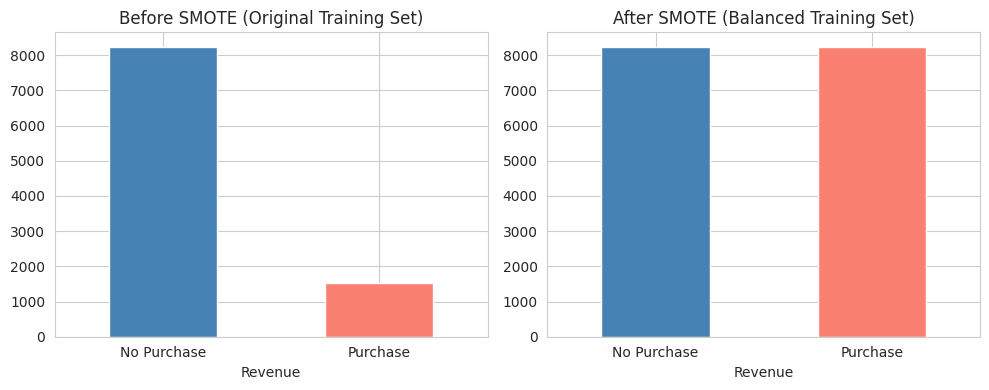

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().sort_index().plot(kind='bar', color=['steelblue', 'salmon'], ax=axes[0])
axes[0].set_title('Before SMOTE (Original Training Set)')
axes[0].set_xticklabels(['No Purchase', 'Purchase'], rotation=0)

y_train_smote.value_counts().sort_index().plot(kind='bar', color=['steelblue', 'salmon'], ax=axes[1])
axes[1].set_title('After SMOTE (Balanced Training Set)')
axes[1].set_xticklabels(['No Purchase', 'Purchase'], rotation=0)

plt.tight_layout()
plt.show()


## 6. Helper Function - Train & Evaluate a Model

To fairly compare all 6 combinations (3 algorithms x 2 strategies), we write one
reusable function that trains a given model on given training data and evaluates it
on the (always untouched, always imbalanced) test set.

**Metrics chosen** (and why they matter more than plain Accuracy for imbalanced data):
- **Precision**: of all sessions we predicted as "will purchase", how many actually did?
  (Important if marketing budget is spent per flagged session.)
- **Recall**: of all sessions that actually purchased, how many did we correctly catch?
  (Important for not missing real buyers.)
- **F1-score**: harmonic mean of Precision & Recall - a balanced single number.
- **ROC-AUC**: overall ranking quality of the model across all thresholds.
- **PR-AUC (Average Precision)**: especially informative for imbalanced problems,
  focuses on the positive (minority) class performance across thresholds.


In [7]:
def train_and_evaluate(model, X_tr, y_tr, X_te, y_te, model_name):
    """Fit `model` on (X_tr, y_tr), evaluate on (X_te, y_te), and return a results dict."""
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]  # probability of the positive class (Purchase)

    results = {
        'Model': model_name,
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1_Score': f1_score(y_te, y_pred),
        'ROC_AUC': roc_auc_score(y_te, y_proba),
        'PR_AUC': average_precision_score(y_te, y_proba),
    }
    return model, results, y_pred, y_proba


## 7. Train All 6 Baseline Models

In [8]:
trained_models = {}
all_results = []
predictions = {}

# ---- Strategy A: class_weight / scale_pos_weight (trained on ORIGINAL imbalanced data) ----

rf_cw = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                class_weight='balanced', n_jobs=-1)
model, res, y_pred, y_proba = train_and_evaluate(rf_cw, X_train, y_train, X_test, y_test,
                                                    'RandomForest_ClassWeight')
trained_models['RandomForest_ClassWeight'] = model
all_results.append(res)
predictions['RandomForest_ClassWeight'] = (y_pred, y_proba)

xgb_cw = xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                            scale_pos_weight=scale_pos_weight,
                            eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
model, res, y_pred, y_proba = train_and_evaluate(xgb_cw, X_train, y_train, X_test, y_test,
                                                    'XGBoost_ClassWeight')
trained_models['XGBoost_ClassWeight'] = model
all_results.append(res)
predictions['XGBoost_ClassWeight'] = (y_pred, y_proba)

lgb_cw = lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE,
                             class_weight='balanced', n_jobs=-1, verbose=-1)
model, res, y_pred, y_proba = train_and_evaluate(lgb_cw, X_train, y_train, X_test, y_test,
                                                    'LightGBM_ClassWeight')
trained_models['LightGBM_ClassWeight'] = model
all_results.append(res)
predictions['LightGBM_ClassWeight'] = (y_pred, y_proba)

print("Strategy A (class weighting) models trained.")


Strategy A (class weighting) models trained.


In [9]:
# ---- Strategy B: SMOTE (trained on SMOTE-BALANCED training data) ----

rf_smote = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
model, res, y_pred, y_proba = train_and_evaluate(rf_smote, X_train_smote, y_train_smote,
                                                    X_test, y_test, 'RandomForest_SMOTE')
trained_models['RandomForest_SMOTE'] = model
all_results.append(res)
predictions['RandomForest_SMOTE'] = (y_pred, y_proba)

xgb_smote = xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                               eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
model, res, y_pred, y_proba = train_and_evaluate(xgb_smote, X_train_smote, y_train_smote,
                                                    X_test, y_test, 'XGBoost_SMOTE')
trained_models['XGBoost_SMOTE'] = model
all_results.append(res)
predictions['XGBoost_SMOTE'] = (y_pred, y_proba)

lgb_smote = lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
model, res, y_pred, y_proba = train_and_evaluate(lgb_smote, X_train_smote, y_train_smote,
                                                    X_test, y_test, 'LightGBM_SMOTE')
trained_models['LightGBM_SMOTE'] = model
all_results.append(res)
predictions['LightGBM_SMOTE'] = (y_pred, y_proba)

print("Strategy B (SMOTE) models trained.")


Strategy B (SMOTE) models trained.


## 8. Compare All 6 Models

In [10]:
results_df = pd.DataFrame(all_results).sort_values('F1_Score', ascending=False).reset_index(drop=True)
results_df


,Model,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,LightGBM_ClassWeight,0.614072,0.753927,0.676851,0.929274,0.737486
1,RandomForest_SMOTE,0.635071,0.701571,0.666667,0.923992,0.710042
2,LightGBM_SMOTE,0.652284,0.672775,0.662371,0.930127,0.739942
3,XGBoost_ClassWeight,0.622596,0.678010,0.649123,0.918605,0.715013
4,XGBoost_SMOTE,0.634715,0.641361,0.638021,0.920357,0.706033
5,RandomForest_ClassWeight,0.723549,0.554974,0.628148,0.923976,0.729759


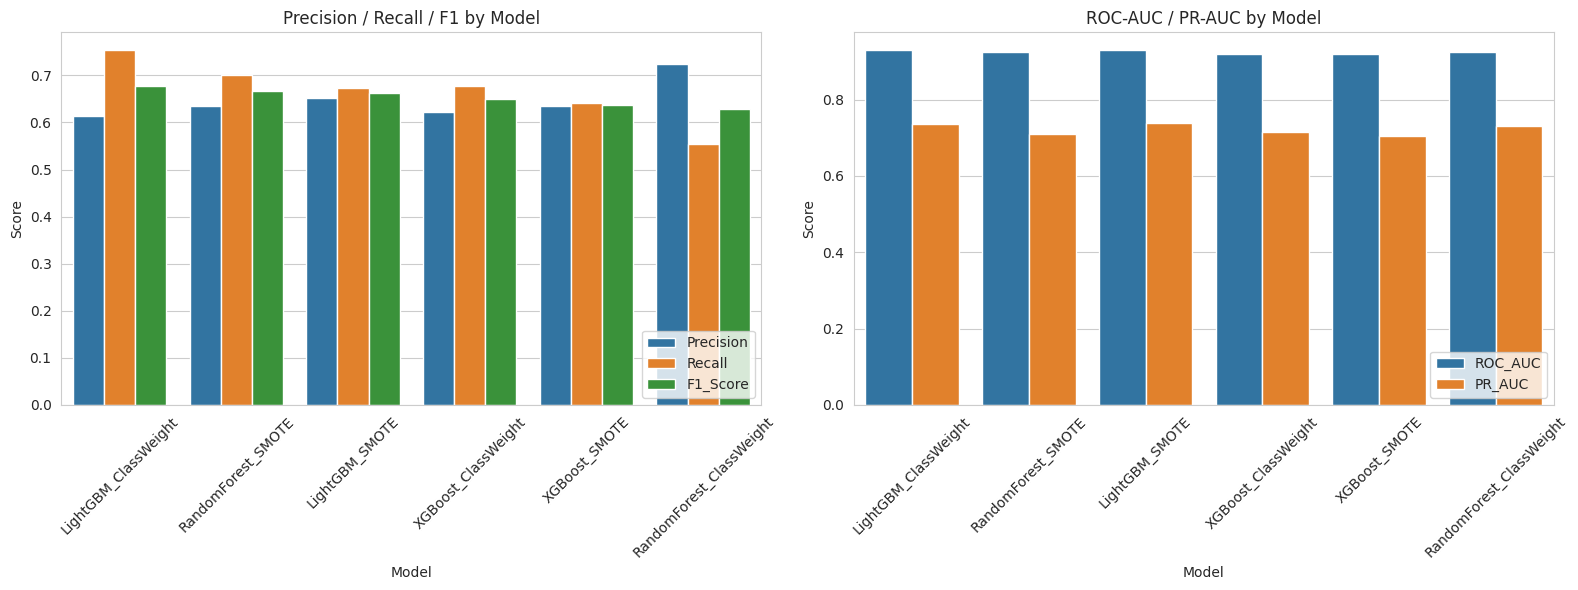

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

results_melted = results_df.melt(id_vars='Model',
                                   value_vars=['Precision', 'Recall', 'F1_Score'],
                                   var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0])
axes[0].set_title('Precision / Recall / F1 by Model')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower right')

results_melted2 = results_df.melt(id_vars='Model',
                                    value_vars=['ROC_AUC', 'PR_AUC'],
                                    var_name='Metric', value_name='Score')
sns.barplot(data=results_melted2, x='Model', y='Score', hue='Metric', ax=axes[1])
axes[1].set_title('ROC-AUC / PR-AUC by Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


**How to read this comparison:**
- Models trained with **class_weight/scale_pos_weight** typically keep the model
  "aware" of the true data distribution while still penalizing minority-class
  mistakes - often giving a good Precision/Recall balance.
- Models trained with **SMOTE** see an artificially balanced training set, which can
  sometimes push Recall higher (catching more real buyers) at some cost to Precision
  (more false alarms), since the model has learned from many synthetic minority
  examples.
- **ROC-AUC** tends to be similar across strategies (it only depends on ranking, not
  the decision threshold), while **PR-AUC** and **F1** are usually more sensitive to
  how imbalance was handled - so pay closest attention to those for this problem.

The best strategy is not always the same across algorithms - that's exactly why we
compare all 6 combinations empirically instead of assuming one approach is always
better.


## 9. Confusion Matrices for All Models

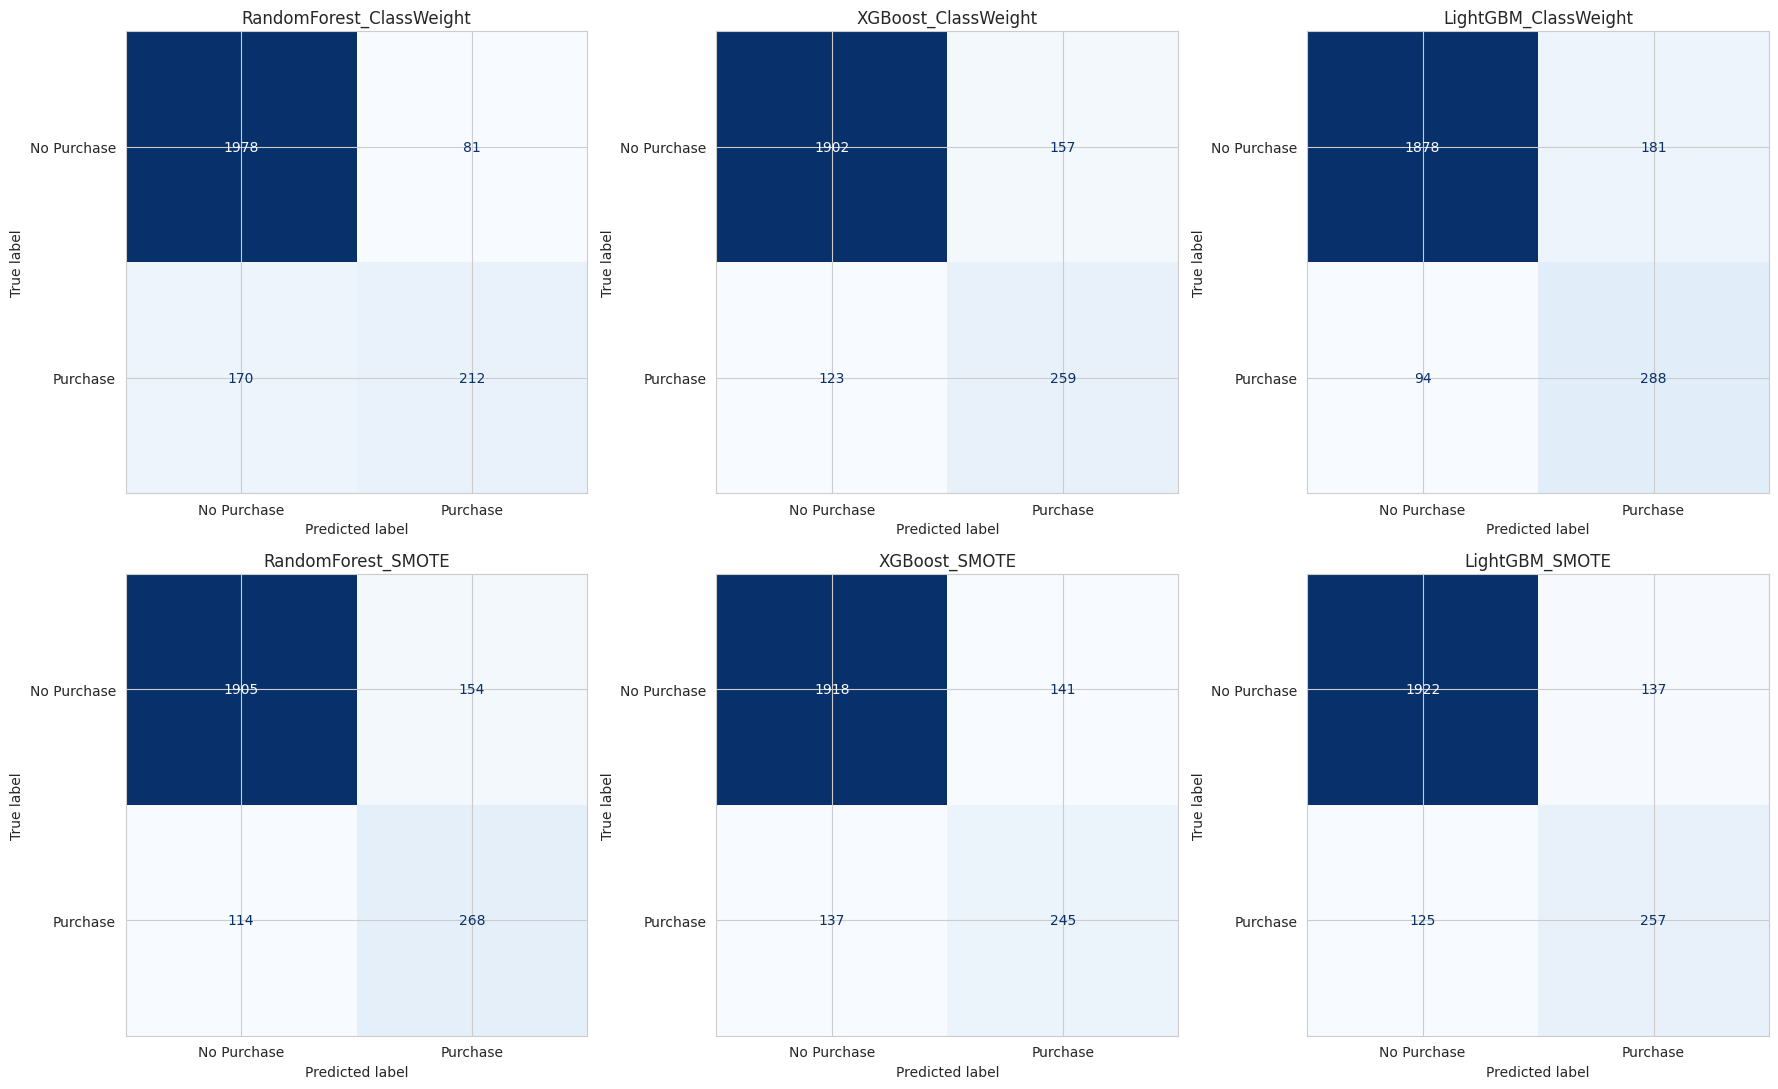

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, model_name in enumerate(trained_models.keys()):
    y_pred, _ = predictions[model_name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(model_name)

plt.tight_layout()
plt.show()


## 10. ROC Curves and Precision-Recall Curves - All Models

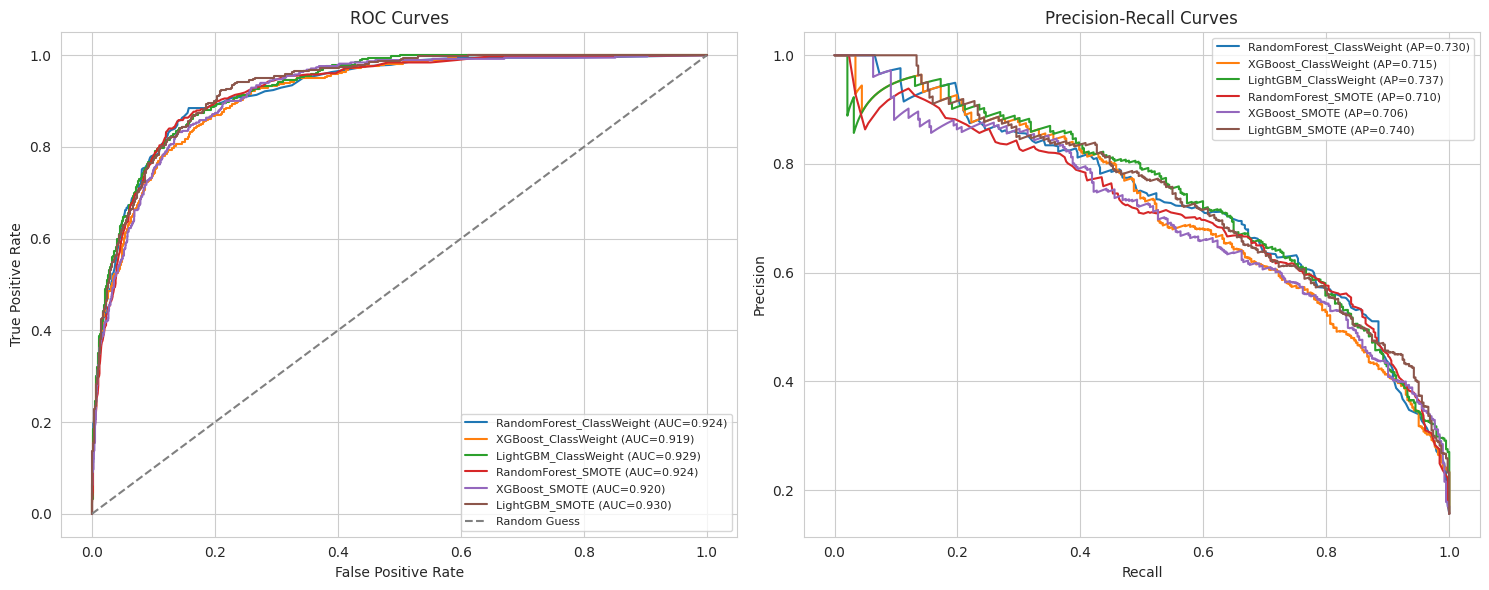

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for model_name in trained_models.keys():
    _, y_proba = predictions[model_name]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_score(y_test, y_proba):.3f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, label=f"{model_name} (AP={average_precision_score(y_test, y_proba):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 11. Feature Importance (Best Model)

Best baseline model by F1-Score: LightGBM_ClassWeight


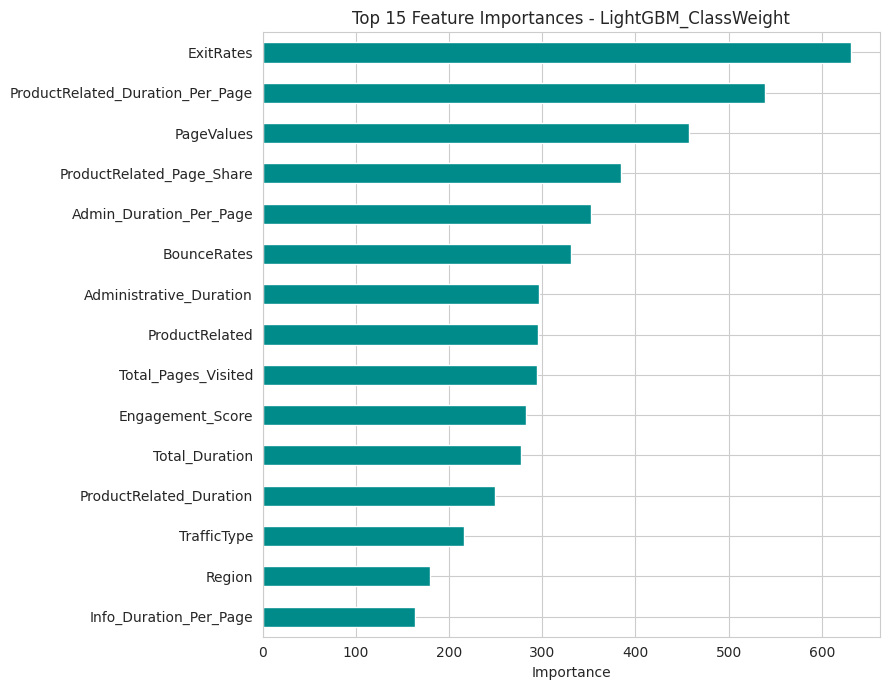

In [14]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Best baseline model by F1-Score: {best_model_name}")

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
importances.sort_values().plot(kind='barh', color='darkcyan')
plt.title(f'Top 15 Feature Importances - {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Observation:** As predicted during EDA and Feature Engineering, `PageValues`
(and our engineered `Has_PageValue` flag) tend to dominate feature importance,
confirming it is the strongest signal of purchase intent. Engagement-related
engineered features (`Engagement_Score`, duration-per-page ratios) also typically
rank among the more useful features, validating our feature engineering work.


## 12. Save All Trained Baseline Models

In [15]:
os.makedirs('../models', exist_ok=True)

for name, model in trained_models.items():
    joblib.dump(model, f'../models/{name}.pkl')

results_df.to_csv('../data/processed/model_comparison_results.csv', index=False)

print("Saved models:")
for f in sorted(os.listdir('../models')):
    print(" -", f)
print()
print("Saved model comparison table to ../data/processed/model_comparison_results.csv")


Saved models:
 - LightGBM_ClassWeight.pkl
 - LightGBM_SMOTE.pkl
 - RandomForest_ClassWeight.pkl
 - RandomForest_SMOTE.pkl
 - XGBoost_ClassWeight.pkl
 - XGBoost_SMOTE.pkl

Saved model comparison table to ../data/processed/model_comparison_results.csv


## 13. Summary

- Trained **3 algorithms** (Random Forest, XGBoost, LightGBM) each with **2
  imbalance-handling strategies** (class weighting vs SMOTE) = **6 baseline models**.
- Compared them using Precision, Recall, F1-Score, ROC-AUC, and PR-AUC on an
  untouched, realistically-imbalanced test set.
- Visualized confusion matrices, ROC curves, and Precision-Recall curves for all
  models.
- Inspected feature importance of the best baseline model, confirming `PageValues`
  and engagement-related features are the strongest predictors.
- Saved all 6 trained models and the comparison results table to disk.

### Next Steps
Proceed to `05_Evaluation_Tuning_CV.ipynb`, where we will:
- Perform **k-fold Stratified Cross-Validation** for robust performance estimates.
- Run **hyperparameter tuning** (RandomizedSearchCV / GridSearchCV) on the most
  promising model/strategy combination(s) identified here.
- Produce a final, thoroughly evaluated model.
